Epoch 1/20 - Train Acc: 0.4540, Test Acc: 0.4320
Epoch 2/20 - Train Acc: 0.5745, Test Acc: 0.5140
Epoch 3/20 - Train Acc: 0.7370, Test Acc: 0.7160
Epoch 4/20 - Train Acc: 0.8295, Test Acc: 0.7700
Epoch 5/20 - Train Acc: 0.8230, Test Acc: 0.7620
Epoch 6/20 - Train Acc: 0.8640, Test Acc: 0.8300
Epoch 7/20 - Train Acc: 0.8610, Test Acc: 0.8320
Epoch 8/20 - Train Acc: 0.8855, Test Acc: 0.8560
Epoch 9/20 - Train Acc: 0.8920, Test Acc: 0.8640
Epoch 10/20 - Train Acc: 0.9030, Test Acc: 0.8580
Epoch 11/20 - Train Acc: 0.9025, Test Acc: 0.8700
Epoch 12/20 - Train Acc: 0.9140, Test Acc: 0.8760
Epoch 13/20 - Train Acc: 0.9170, Test Acc: 0.8800
Epoch 14/20 - Train Acc: 0.9230, Test Acc: 0.8780
Epoch 15/20 - Train Acc: 0.9275, Test Acc: 0.8760
Epoch 16/20 - Train Acc: 0.9245, Test Acc: 0.8760
Epoch 17/20 - Train Acc: 0.9370, Test Acc: 0.8940
Epoch 18/20 - Train Acc: 0.9320, Test Acc: 0.8860
Epoch 19/20 - Train Acc: 0.9365, Test Acc: 0.8860
Epoch 20/20 - Train Acc: 0.9425, Test Acc: 0.8960


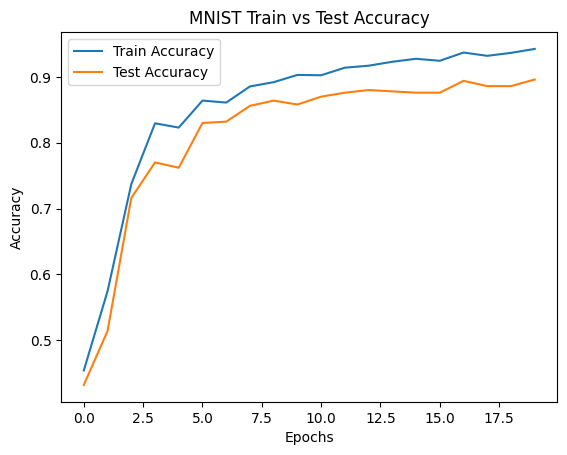

In [11]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt


mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
X = X[:2500]
y = y[:2500]


encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))


X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)


input_dim = X_train.shape[1]  
hidden_dim = 128
output_dim = 10
lr = 0.1
epochs = 20
batch_size = 64
drop_prob = 0.5
lambda_reg = 0.001


np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))


def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))



def forward(X, W1, b1, W2, b2, drop_prob=0.0, train=True):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    mask = None
    if train and drop_prob > 0.0:
        mask = (np.random.rand(*a1.shape) > drop_prob) / (1 - drop_prob)
        a1 *= mask
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2, mask


def backward(X, y, z1, a1, a2, W1, W2, b1, b2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    dz2 = a2 - y
    dW2 = (a1.T @ dz2) / m + lambda_reg * W2
    db2 = np.sum(dz2, axis=0, keepdims=True) / m
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1) / m + lambda_reg * W1
    db1 = np.sum(dz1, axis=0, keepdims=True) / m
    W1_new = W1 - lr * dW1
    b1_new = b1 - lr * db1
    W2_new = W2 - lr * dW2
    b2_new = b2 - lr * db2
    return W1_new, b1_new, W2_new, b2_new


train_acc_history, test_acc_history = [], []

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]
    
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]
        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2 = backward(X_batch, y_batch, z1, a1, a2, W1, W2, b1, b2, mask, lr, lambda_reg)
    
  
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")


plt.plot(train_acc_history, label='Train Accuracy')
plt.plot(test_acc_history, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('MNIST Train vs Test Accuracy')
plt.legend()
plt.show()

In [13]:

import numpy as np
import json
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)

X = X[:2500]
y = y[:2500]
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)


input_dim = X_train.shape[1]
hidden_dim = 128
output_dim = 10
lr = 0.1
epochs = 15
batch_size = 64
drop_prob = 0.5
lambda_reg = 0.001

np.random.seed(42)
W1 = np.random.randn(input_dim, hidden_dim) * 0.01
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.01
b2 = np.zeros((1, output_dim))


def relu(x): return np.maximum(0, x)
def relu_derivative(x): return (x > 0).astype(float)
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)
def accuracy(y_true, y_pred):
    return np.mean(np.argmax(y_true, axis=1) == np.argmax(y_pred, axis=1))

def forward(X, W1, b1, W2, b2, drop_prob=0.0, train=True):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    mask = None
    if train and drop_prob > 0.0:
        mask = (np.random.rand(*a1.shape) > drop_prob) / (1 - drop_prob)
        a1 *= mask
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return z1, a1, z2, a2, mask

def backward(X, y, z1, a1, a2, W1, W2, b1, b2, mask=None, lr=0.01, lambda_reg=0.001):
    m = X.shape[0]
    dz2 = a2 - y
    dW2 = (a1.T @ dz2)/m + lambda_reg*W2
    db2 = np.sum(dz2, axis=0, keepdims=True)/m
    da1 = dz2 @ W2.T
    if mask is not None:
        da1 *= mask
    dz1 = da1 * relu_derivative(z1)
    dW1 = (X.T @ dz1)/m + lambda_reg*W1
    db1 = np.sum(dz1, axis=0, keepdims=True)/m

    W1_new = W1 - lr*dW1
    b1_new = b1 - lr*db1
    W2_new = W2 - lr*dW2
    b2_new = b2 - lr*db2

    grads = {'dW1': dW1.tolist(), 'db1': db1.tolist(),
             'dW2': dW2.tolist(), 'db2': db2.tolist()}
    return W1_new, b1_new, W2_new, b2_new, grads


train_acc_history = []
test_acc_history = []


with open('mnist_xai_500.json', 'w') as f:
    pass

for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[idx]
    y_train_shuffled = y_train[idx]

    for i in range(0, len(X_train), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        y_batch = y_train_shuffled[i:i+batch_size]

        z1, a1, z2, a2, mask = forward(X_batch, W1, b1, W2, b2, drop_prob, train=True)
        W1, b1, W2, b2, grads = backward(X_batch, y_batch, z1, a1, a2, W1, W2, b1, b2, mask, lr, lambda_reg)

  
        batch_record = {
            'epoch': epoch+1,
            'batch_index': i//batch_size,
            'inputs': X_batch.tolist(),
            'true_labels': y_batch.tolist(),
            'predictions': a2.tolist(),
            'weights': {'W1': W1.tolist(), 'b1': b1.tolist(),
                        'W2': W2.tolist(), 'b2': b2.tolist()},
            'gradients': grads,
            'activations': {'z1': z1.tolist(), 'a1': a1.tolist(),
                            'z2': z2.tolist(), 'a2': a2.tolist()},
            'dropout_mask': mask.tolist() if mask is not None else None
        }

        with open('mnist_xai_500.json', 'a') as f:
            json.dump(batch_record, f)
            f.write('\n')

 
    _, _, _, train_pred, _ = forward(X_train, W1, b1, W2, b2, drop_prob=0.0, train=False)
    _, _, _, test_pred, _ = forward(X_test, W1, b1, W2, b2, drop_prob=0.0, train=False)
    train_acc = accuracy(y_train, train_pred)
    test_acc = accuracy(y_test, test_pred)
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)
    print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

print("✅ XAI data saved batch by batch in mnist_xai_500.json")

Epoch 1/15 - Train Acc: 0.4540, Test Acc: 0.4320
Epoch 2/15 - Train Acc: 0.5745, Test Acc: 0.5140
Epoch 3/15 - Train Acc: 0.7370, Test Acc: 0.7160
Epoch 4/15 - Train Acc: 0.8295, Test Acc: 0.7700
Epoch 5/15 - Train Acc: 0.8230, Test Acc: 0.7620
Epoch 6/15 - Train Acc: 0.8640, Test Acc: 0.8300
Epoch 7/15 - Train Acc: 0.8610, Test Acc: 0.8320
Epoch 8/15 - Train Acc: 0.8855, Test Acc: 0.8560
Epoch 9/15 - Train Acc: 0.8920, Test Acc: 0.8640
Epoch 10/15 - Train Acc: 0.9030, Test Acc: 0.8580
Epoch 11/15 - Train Acc: 0.9025, Test Acc: 0.8700
Epoch 12/15 - Train Acc: 0.9140, Test Acc: 0.8760
Epoch 13/15 - Train Acc: 0.9170, Test Acc: 0.8800
Epoch 14/15 - Train Acc: 0.9230, Test Acc: 0.8780
Epoch 15/15 - Train Acc: 0.9275, Test Acc: 0.8760
✅ XAI data saved batch by batch in mnist_xai_500.json


In [15]:
np.savez_compressed("mnist_xai_2500.npz", W1=W1, W2=W2, b1=b1, b2=b2)

In [8]:
print(X_train.shape)

(56000, 784)


In [1]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import matplotlib.pyplot as plt


mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
X = X[:2500]
y = y[:2500]


In [2]:
import json

sample = X[0].tolist()   # one MNIST image
print(json.dumps({"pixels": sample}))

{"pixels": [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0117647061124444, 0.07058823853731155, 0.07058823853731155, 0.07058823853731155, 0.4941176474094391, 0.5333333611488342, 0.686274528503418, 0.10196078568696976, 0.6509804129600525, 1.0, 0.9686274528503418, 0.49803921580314636,

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Convert labels to integers
y = y.astype(np.int8)

# Get all images of digit 9
digit_9_indices = np.where(y == 9)[0]       # indices where label is 9
X_9 = X[digit_9_indices]                    # corresponding images
y_9 = y[digit_9_indices]                    # labels (all 9s)

print("Number of 9s in dataset:", X_9.shape[0])
print("Shape of each image:", X_9[0].shape)

Number of 9s in dataset: 6958
Shape of each image: (784,)


Shape of input pixels: (784,)
Label: 9


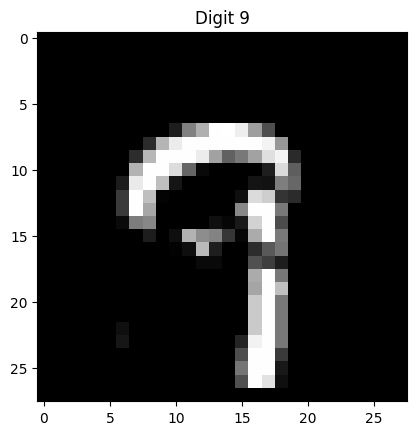

In [2]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.int8)

# Find indices of all 9s
digit_9_indices = np.where(y == 9)[0]

# Pick one random 9
idx = np.random.choice(digit_9_indices)
X_9 = X[idx]  # This is a 784-length array (28x28 flattened)
y_9 = y[idx]  # Should be 9

print("Shape of input pixels:", X_9.shape)
print("Label:", y_9)

# Optional: reshape to 28x28 for visualization
import matplotlib.pyplot as plt
plt.imshow(X_9.reshape(28,28), cmap='gray')
plt.title("Digit 9")
plt.show()

Shape of input pixels: (784,)
Label: 5


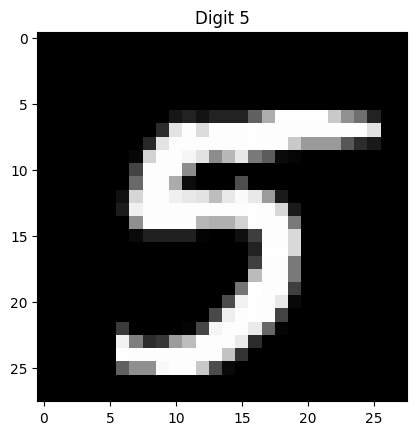

In [3]:
import numpy as np
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.int8)

# Find indices of all 5s
digit_5_indices = np.where(y == 5)[0]

# Pick one random 5
idx = np.random.choice(digit_5_indices)
X_5 = X[idx]  # 784-length array (28x28 flattened)
y_5 = y[idx]  # Should be 5

print("Shape of input pixels:", X_5.shape)
print("Label:", y_5)

# Reshape to 28x28 for visualization
plt.imshow(X_5.reshape(28, 28), cmap='gray')
plt.title("Digit 5")
plt.show()

In [2]:
import numpy as np

data = np.load("mnist_api/predictor/mnist_xai_2500.npz")

print("Keys in file:", data.files)

Keys in file: ['W1', 'W2', 'b1', 'b2']


In [3]:
for key in data.files:
    print(key, data[key].shape)

W1 (784, 128)
W2 (128, 10)
b1 (1, 128)
b2 (1, 10)


In [4]:
print(data["W1"][:5, :5])
print(data["b1"][:10])

[[ 0.00473434 -0.00131784  0.00617332  0.01451648 -0.00223179]
 [ 0.00094981 -0.00479879 -0.01477986  0.0006535  -0.01012515]
 [ 0.01207533 -0.00674502  0.00423018  0.00738328 -0.00883487]
 [-0.00723553  0.00143345  0.00325738  0.01788238  0.00905879]
 [-0.00227749 -0.00865028 -0.00549739  0.00719987  0.0047744 ]]
[[ 0.00081457  0.00920565  0.04487315  0.00177186  0.0179388   0.0359838
  -0.00185108  0.00674387 -0.00909835  0.00103407  0.01001701  0.03306632
   0.0024742   0.02543792  0.01873597  0.05116794  0.00440308  0.04462451
   0.02791377  0.01238368 -0.03385835 -0.02847822  0.04404212  0.00053798
   0.04891695  0.03283069  0.06828561  0.02715613 -0.04342839 -0.00794607
   0.00662604  0.04873624 -0.01204331  0.01283534  0.05762046  0.02162444
  -0.00532772 -0.00130695  0.03484519  0.03857708  0.03846889 -0.00372303
   0.0340652   0.05117092  0.01773443  0.01737972  0.04199131  0.00522654
   0.0248782   0.04150644  0.03849784  0.03869079 -0.06495973 -0.03518125
   0.01173472 -0.00

In [5]:
import json

weights_json = {key: data[key].tolist() for key in data.files}

with open("weights.json", "w") as f:
    json.dump(weights_json, f, indent=2)

print("Saved as weights.json")

Saved as weights.json


In [6]:
import pprint
pprint.pprint({k: data[k].flatten()[:10].tolist() for k in data.files})

{'W1': [0.004734339054360994,
        -0.0013178406068970372,
        0.006173323474684127,
        0.014516477306792744,
        -0.0022317895714118047,
        -0.002231633088434822,
        0.015051974787267544,
        0.007314662140942469,
        -0.004474708253991964,
        0.005171310678612271],
 'W2': [-0.17153471733291736,
        0.18953634880750378,
        0.1692758658571253,
        0.2372245405166163,
        -0.11604948160533743,
        -0.18505267955207827,
        -0.12713718215297776,
        0.17005813035909845,
        -0.05522868418818923,
        -0.11122535021944044],
 'b1': [0.000814574971448166,
        0.009205647915793707,
        0.0448731466540518,
        0.0017718559347265584,
        0.0179388009767621,
        0.035983804257886484,
        -0.0018510764401645599,
        0.006743872689170685,
        -0.00909834517941043,
        0.0010340725063806796],
 'b2': [-0.28503546214773906,
        0.3087556387992966,
        -0.1502645386074092,
        -0

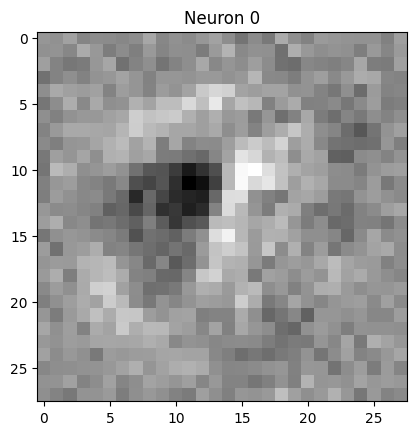

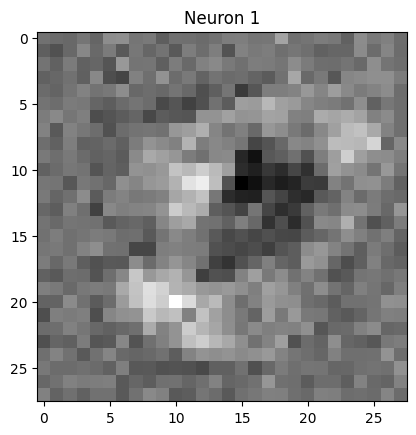

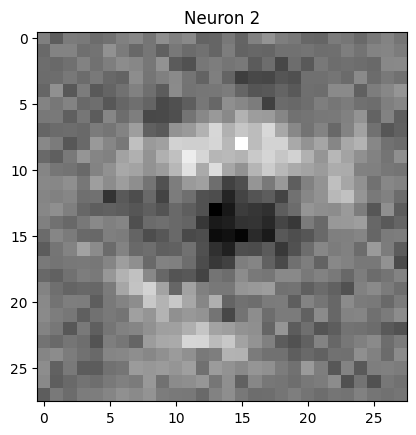

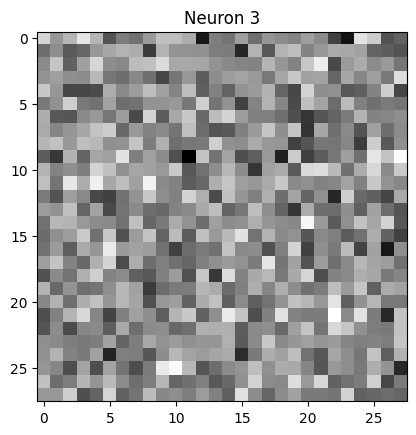

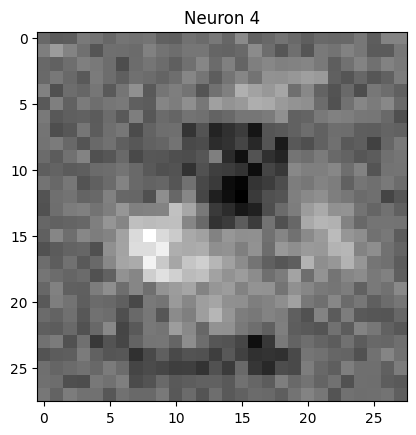

In [7]:
import matplotlib.pyplot as plt

W1 = data["W1"]

for i in range(5):
    plt.imshow(W1[:, i].reshape(28,28), cmap="gray")
    plt.title(f"Neuron {i}")
    plt.show()

NameError: name 'b1' is not defined

In [9]:
def saliency_map(X):
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)  # ReLU
    z2 = a1 @ W2 + b2
    e = np.exp(z2 - np.max(z2, axis=1, keepdims=True))
    probs = e / np.sum(e, axis=1, keepdims=True)

    pred_class = np.argmax(probs)
    dz2 = np.zeros_like(z2)
    dz2[0, pred_class] = 1
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    dX = dz1 @ W1.T

    importance = np.abs(dX)
    importance /= np.max(importance) + 1e-8
    return importance.reshape(28,28), probs

In [11]:
X = np.random.rand(1,784)
heatmap, probs = saliency_map(X)

import matplotlib.pyplot as plt
plt.imshow(heatmap, cmap="hot")
plt.title("Saliency Map")
plt.show()

NameError: name 'b1' is not defined